1. Mount Google Drive

In [ ]:
!git clone https://github.com/heathclif-cyber/Riset_pemodelan.git

%cd /workspace/Riset_pemodelan

In [6]:
!pip install -q \
    lightgbm \
    torch \
    scikit-learn \
    shap \
    pyarrow \
    joblib \
    pandas \
    numpy \
    pickleshare \
    matplotlib


[notice] A new release of pip is available: 24.2 -> 26.1
[notice] To update, run: python -m pip install --upgrade pip


In [7]:
import torch
print(f"CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Device: {torch.cuda.get_device_name(0)}")

CUDA: True
Device: NVIDIA GeForce RTX 3090


In [8]:
%cd /workspace/Riset_pemodelan

/workspace/Riset_pemodelan


In [9]:
# Fetch 15 koin tambahan
# Estimasi waktu: 1-2 jam
!python pipeline/01_fetch.py --all --reset

2026-05-03 13:07:46 | INFO     | 01_fetch | ============================================================
2026-05-03 13:07:46 | INFO     | 01_fetch |   FETCH DATA: ALL COINS (2020-01-01 → 2026-04-01)
2026-05-03 13:07:46 | INFO     | 01_fetch |   Koin    : ['SOLUSDT', 'ETHUSDT', 'BNBUSDT', 'XRPUSDT', 'DOGEUSDT', 'TONUSDT', 'ADAUSDT', 'TRXUSDT', '1000SHIBUSDT', 'AVAXUSDT', 'LINKUSDT', 'DOTUSDT', 'SUIUSDT', 'POLUSDT', 'NEARUSDT', '1000PEPEUSDT', 'TAOUSDT', 'ARBUSDT']
2026-05-03 13:07:46 | INFO     | 01_fetch |   Macro   : 2020-01-01 → 2026-04-01
2026-05-03 13:07:46 | INFO     | 01_fetch | ============================================================
2026-05-03 13:07:46 | INFO     | 01_fetch | Progress di-reset.
2026-05-03 13:07:46 | INFO     | binance_client | ✅ Connection OK via futures
2026-05-03 13:07:46 | INFO     | 01_fetch | Koneksi Binance OK.
2026-05-03 13:07:46 | INFO     | 01_fetch | 
--- FETCH MACRO DATA ---
2026-05-03 13:07:46 | INFO     | fetchers | ============================

In [10]:
!sed -i 's|https://fapi.binance.com|https://data-api.binance.vision|g' /workspace/Riset_pemodelan/config.py

In [11]:
import os
files = list(os.walk('data/raw/klines'))
for root, dirs, fs in files[:5]:
    print(root, len(fs), 'files')

data/raw/klines 0 files
data/raw/klines/ARBUSDT 3 files
data/raw/klines/TAOUSDT 3 files
data/raw/klines/1000PEPEUSDT 3 files
data/raw/klines/NEARUSDT 3 files


In [12]:
!python pipeline/02_clean.py --all

2026-05-03 13:13:04 | INFO     | 02_clean | [SOLUSDT] Starting cleaning...
2026-05-03 13:13:04 | INFO     | 02_clean | [SOLUSDT] 1h: 48,593 rows, 0 gaps
2026-05-03 13:13:04 | INFO     | 02_clean | [SOLUSDT] 4h: 12,149 rows, 0 gaps
2026-05-03 13:13:04 | INFO     | 02_clean | [SOLUSDT] 1d: 2,025 rows, 0 gaps
2026-05-03 13:13:04 | INFO     | 02_clean | [SOLUSDT] Saved → /workspace/Riset_pemodelan/data/processed/SOLUSDT_clean.parquet (48,593 rows × 29 cols)
2026-05-03 13:13:04 | INFO     | 02_clean | [ETHUSDT] Starting cleaning...
2026-05-03 13:13:04 | INFO     | 02_clean | [ETHUSDT] 1h: 54,768 rows, 0 gaps
2026-05-03 13:13:04 | INFO     | 02_clean | [ETHUSDT] 4h: 13,692 rows, 0 gaps
2026-05-03 13:13:04 | INFO     | 02_clean | [ETHUSDT] 1d: 2,282 rows, 0 gaps
2026-05-03 13:13:05 | INFO     | 02_clean | [ETHUSDT] Saved → /workspace/Riset_pemodelan/data/processed/ETHUSDT_clean.parquet (54,768 rows × 29 cols)
2026-05-03 13:13:05 | INFO     | 02_clean | [BNBUSDT] Starting cleaning...
2026-05-0

In [13]:
!grep -n "calc_ofi_features\|calc_vwdp\|calc_vsa" /workspace/Riset_pemodelan/core/features.py

646:def calc_ofi_features(
682:def calc_vwdp(
777:def calc_vsa_features(
1404:    ofi_feats = calc_ofi_features(
1413:    vwdp_feats = calc_vwdp(
1442:    vsa_feats = calc_vsa_features(


In [14]:
!python pipeline/03_engineer.py --all

2026-05-03 13:13:11 | INFO     | 03_engineer | [SOLUSDT] Starting feature engineering v3...
2026-05-03 13:13:44 | INFO     | features | [SOLUSDT] Swing-Based labeling v3 (max_hold=24h, min_rr=1.2, min_tp=1.2×ATR, max_sl=3.0×ATR)...
2026-05-03 13:13:44 | INFO     | features | Structural filter: 522 LONG → FLAT, 516 SHORT → FLAT
2026-05-03 13:13:44 | INFO     | features | [SOLUSDT] Label distribution v3: LONG=5368 (11.0%), SHORT=5806 (11.9%), FLAT=37419 (77.0%)
2026-05-03 13:13:44 | INFO     | features | [SOLUSDT] Features v3: 48,593 rows × 101 cols | NaN: 1.0%
2026-05-03 13:13:45 | INFO     | 03_engineer | [SOLUSDT] Saved 48580 rows to SOLUSDT_features_v3.parquet
2026-05-03 13:13:45 | INFO     | 03_engineer | [ETHUSDT] Starting feature engineering v3...
2026-05-03 13:14:22 | INFO     | features | [ETHUSDT] Swing-Based labeling v3 (max_hold=24h, min_rr=1.2, min_tp=1.2×ATR, max_sl=3.0×ATR)...
2026-05-03 13:14:22 | INFO     | features | Structural filter: 663 LONG → FLAT, 548 SHORT → FLAT


In [15]:
!python pipeline/analyze_min_hold.py --save-plot

[INFO] LABEL_DIR      = /workspace/Riset_pemodelan/data/labeled
[INFO] MAX_HOLDING_BARS = 24
  Loading 1000PEPEUSDT...
    25,459 rows | cols: ['open', 'high', 'low', 'close', 'volume', 'volume_delta', 'cvd', 'buy_volume']...
    → 6,010 entries LONG/SHORT | median=3h | p10=1h
  Loading 1000SHIBUSDT...
    42,858 rows | cols: ['open', 'high', 'low', 'close', 'volume', 'volume_delta', 'cvd', 'buy_volume']...
    → 10,214 entries LONG/SHORT | median=3h | p10=2h
  Loading ADAUSDT...
    54,027 rows | cols: ['open', 'high', 'low', 'close', 'volume', 'volume_delta', 'cvd', 'buy_volume']...
    → 12,488 entries LONG/SHORT | median=3h | p10=2h
  Loading ARBUSDT...
    26,492 rows | cols: ['open', 'high', 'low', 'close', 'volume', 'volume_delta', 'cvd', 'buy_volume']...
    → 5,937 entries LONG/SHORT | median=3h | p10=2h
  Loading AVAXUSDT...
    48,364 rows | cols: ['open', 'high', 'low', 'close', 'volume', 'volume_delta', 'cvd', 'buy_volume']...
    → 11,004 entries LONG/SHORT | median=3h | 

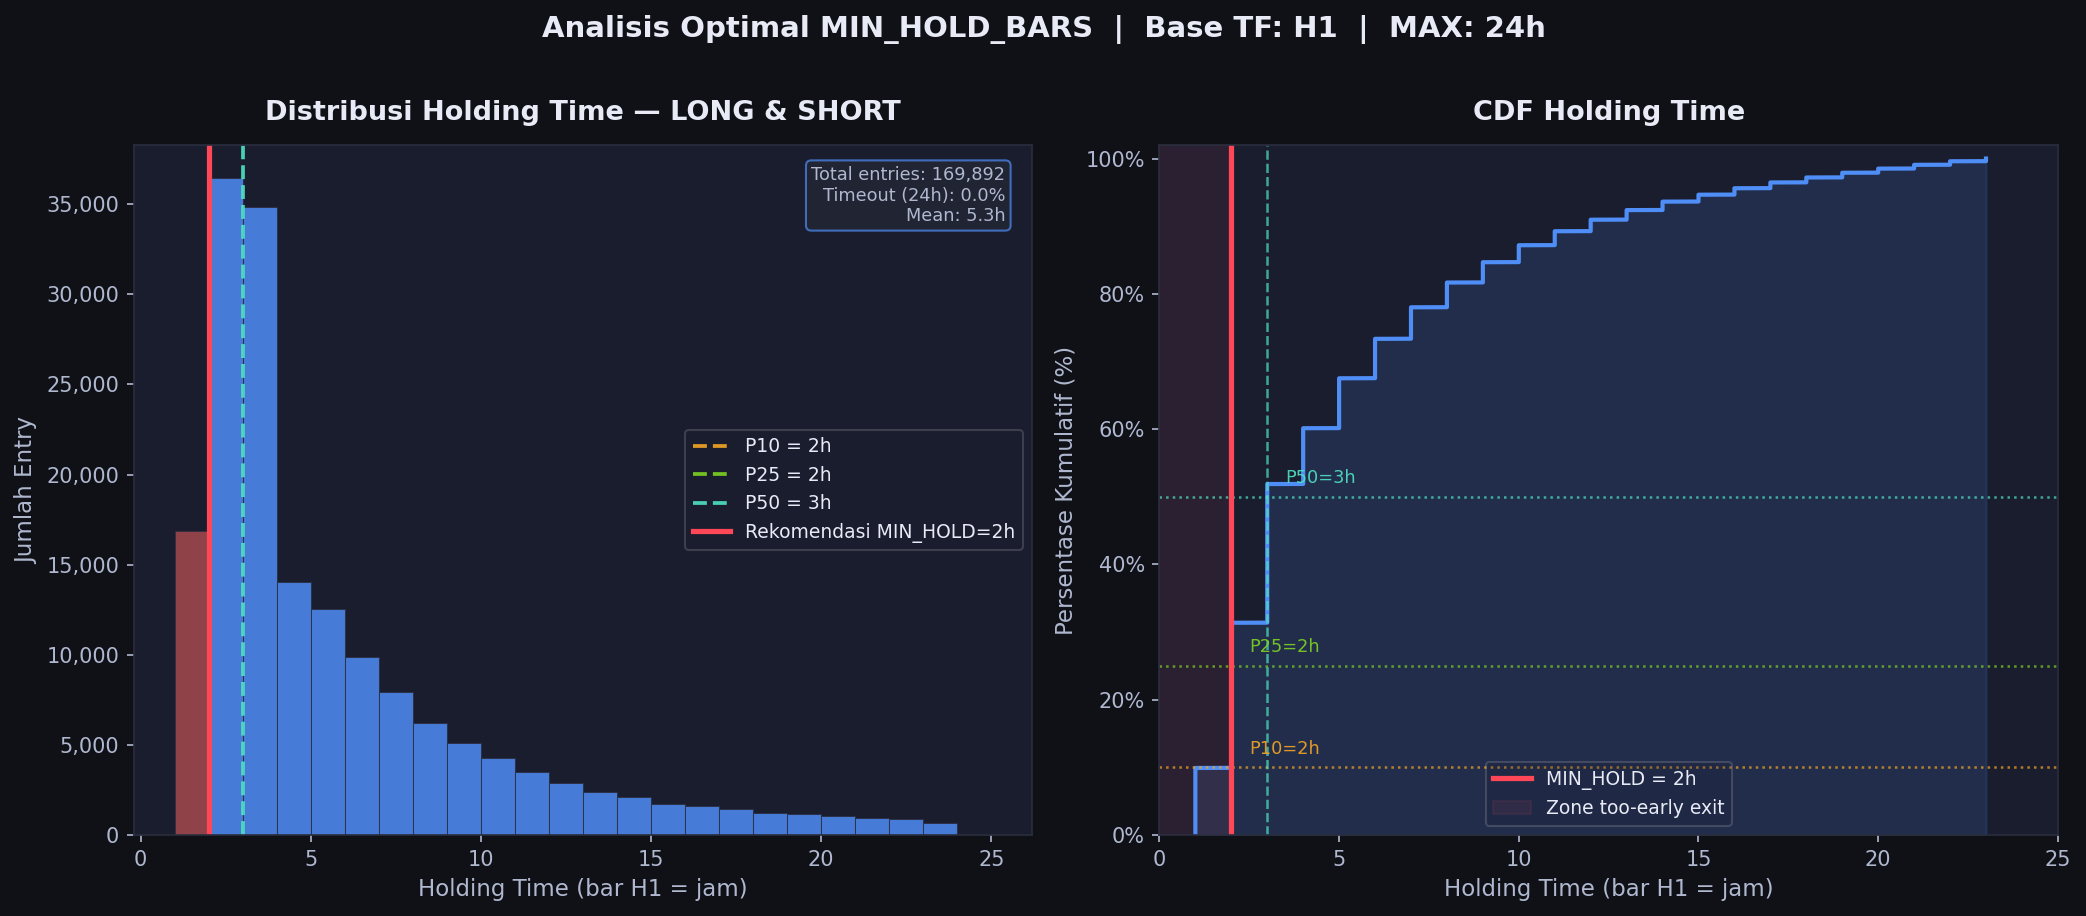

In [16]:
from IPython.display import Image

# Gunakan absolute path RunPod
Image("/workspace/Riset_pemodelan/reports/min_hold_analysis.png")

In [17]:
# Fase 04: Latih H4 LGBM (Regime Filter)
# Bias gate: menentukan apakah market sedang LONG/SHORT/FLAT di TF H4
# Estimasi waktu: 15-30 menit
!python pipeline/04_train_lgbm_h4.py --all

2026-05-03 13:22:12 | INFO     | 04_train_lgbm_h4 | [H4 LGBM] Run ID: run_20260503_132212 | Output: /workspace/Riset_pemodelan/models/runs/run_20260503_132212
2026-05-03 13:22:13 | INFO     | 04_train_lgbm_h4 | [SOLUSDT] H4 labels: LONG=21.7% SHORT=21.4% FLAT=56.9% | total=12,145 bars
2026-05-03 13:22:13 | INFO     | 04_train_lgbm_h4 | [SOLUSDT] H4 resampled: 12,145 bars × 32 features
2026-05-03 13:22:13 | INFO     | 04_train_lgbm_h4 | [ETHUSDT] H4 labels: LONG=22.6% SHORT=21.3% FLAT=56.1% | total=13,689 bars
2026-05-03 13:22:13 | INFO     | 04_train_lgbm_h4 | [ETHUSDT] H4 resampled: 13,689 bars × 32 features
2026-05-03 13:22:13 | INFO     | 04_train_lgbm_h4 | [BNBUSDT] H4 labels: LONG=21.4% SHORT=21.5% FLAT=57.1% | total=13,447 bars
2026-05-03 13:22:13 | INFO     | 04_train_lgbm_h4 | [BNBUSDT] H4 resampled: 13,447 bars × 32 features
2026-05-03 13:22:13 | INFO     | 04_train_lgbm_h4 | [XRPUSDT] H4 labels: LONG=21.0% SHORT=21.7% FLAT=57.3% | total=13,657 bars
2026-05-03 13:22:13 | INFO 

In [18]:
# Fase 05: Latih H1 LGBM (Entry Signal Generator)
# Cost-sensitive class weights: SHORT=3x, FLAT=1x, LONG=3x
# Estimasi waktu: 15-30 menit
!python pipeline/05_train_lgbm_h1.py --all

2026-05-03 13:24:38 | INFO     | 05_train_lgbm_h1 | Run ID: run_20260503_132438 | Output: /workspace/Riset_pemodelan/models/runs/run_20260503_132438
2026-05-03 13:24:38 | INFO     | 05_train_lgbm_h1 | Loaded SOLUSDT: 48,580 rows
2026-05-03 13:24:38 | INFO     | 05_train_lgbm_h1 | Loaded ETHUSDT: 54,755 rows
2026-05-03 13:24:38 | INFO     | 05_train_lgbm_h1 | Loaded BNBUSDT: 53,787 rows
2026-05-03 13:24:38 | INFO     | 05_train_lgbm_h1 | Loaded XRPUSDT: 54,627 rows
2026-05-03 13:24:38 | INFO     | 05_train_lgbm_h1 | Loaded DOGEUSDT: 50,162 rows
2026-05-03 13:24:38 | INFO     | 05_train_lgbm_h1 | Loaded TONUSDT: 18,239 rows
2026-05-03 13:24:38 | INFO     | 05_train_lgbm_h1 | Loaded ADAUSDT: 54,027 rows
2026-05-03 13:24:38 | INFO     | 05_train_lgbm_h1 | Loaded TRXUSDT: 54,411 rows
2026-05-03 13:24:38 | INFO     | 05_train_lgbm_h1 | Loaded 1000SHIBUSDT: 42,858 rows
2026-05-03 13:24:38 | INFO     | 05_train_lgbm_h1 | Loaded AVAXUSDT: 48,364 rows
2026-05-03 13:24:38 | INFO     | 05_train_lg

In [27]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 3090


In [28]:
# Fase 06: Latih LSTM (Momentum Confirmation Vote)
# LSTM berperan sebagai konfirmasi akhir cascade sebelum sinyal diterbitkan
# Estimasi waktu: 30-60 menit (GPU T4 direkomendasikan)
!python pipeline/06_train_lstm.py --all

2026-05-03 13:34:52 | INFO     | 06_train_lstm | Device: cuda | Run: run_20260503_133452
2026-05-03 13:34:52 | INFO     | 06_train_lstm | Loaded SOLUSDT: 48,580 rows
2026-05-03 13:34:52 | INFO     | 06_train_lstm | Loaded ETHUSDT: 54,755 rows
2026-05-03 13:34:53 | INFO     | 06_train_lstm | Loaded BNBUSDT: 53,787 rows
2026-05-03 13:34:53 | INFO     | 06_train_lstm | Loaded XRPUSDT: 54,627 rows
2026-05-03 13:34:53 | INFO     | 06_train_lstm | Loaded DOGEUSDT: 50,162 rows
2026-05-03 13:34:53 | INFO     | 06_train_lstm | Loaded TONUSDT: 18,239 rows
2026-05-03 13:34:54 | INFO     | 06_train_lstm | Loaded ADAUSDT: 54,027 rows
2026-05-03 13:34:54 | INFO     | 06_train_lstm | Loaded TRXUSDT: 54,411 rows
2026-05-03 13:34:54 | INFO     | 06_train_lstm | Loaded 1000SHIBUSDT: 42,858 rows
2026-05-03 13:34:54 | INFO     | 06_train_lstm | Loaded AVAXUSDT: 48,364 rows
2026-05-03 13:34:55 | INFO     | 06_train_lstm | Loaded LINKUSDT: 54,363 rows
2026-05-03 13:34:55 | INFO     | 06_train_lstm | Loaded 

In [29]:
# NOTE: Meta-learner (06_ensemble.py) sudah DIHAPUS dari arsitektur.
#
# Arsitektur baru: Hierarchical Decision Cascade
#   STEP 1  04_train_lgbm_h4.py -> H4 LGBM bias (LONG / SHORT / FLAT)
#   STEP 2  05_train_lgbm_h1.py -> H1 LGBM entry probability
#   STEP 3  06_train_lstm.py    -> LSTM confirmation vote
#   STEP 4  Decision layer      -> sinyal diterbitkan jika ketiga sepakat
#
# Logic cascade ada di: pipeline/backtest_utils.py (hierarchical_predict)
#                   dan: swint_tradev2/app/services/inference.py
print("Hierarchical Cascade aktif. Tidak ada ensemble step. Lanjut ke Fase 07.")

Hierarchical Cascade aktif. Tidak ada ensemble step. Lanjut ke Fase 07.


In [30]:
!grep "def " /workspace/Riset_pemodelan/core/evaluator.py

def simulate_trades(
def simulate_trades_swing(
def calc_drawdown(equity_curve: list, modal_per_trade: float = 100.0) -> dict:
def calc_consecutive_loss(pnl_per_trade: list) -> int:
def calc_trade_per_month(total_trades: int, index: pd.DatetimeIndex) -> float:
def calc_risk_metrics(
def full_trading_report(
    def run_sim(lev):


In [31]:
import json
from pathlib import Path

registry = {
    "active": "hierarchical_cascade",
    "architecture": "Hierarchical Decision Cascade (H4 LGBM → H1 LGBM → LSTM)",
    "models": {
        "h4_lgbm": {
            "version": "v3",
            "role": "Regime Filter (binary: LONG/SHORT/FLAT)",
            "status": "active",
            "f1_macro": None,
            "winrate": None,
            "trade_per_month": None,
            "pnl_lev5x": None,
            "max_drawdown": None,
            "max_consecutive_loss": None,
            "trained_date": None,
        },
        "h1_lgbm": {
            "version": "v3",
            "role": "Entry Signal Generator (3-class: SHORT/FLAT/LONG)",
            "status": "active",
            "f1_macro": None,
            "winrate": None,
            "trade_per_month": None,
            "pnl_lev5x": None,
            "max_drawdown": None,
            "max_consecutive_loss": None,
            "trained_date": None,
        },
        "lstm": {
            "version": "v3",
            "role": "Momentum Confirmation Vote",
            "status": "active",
            "f1_macro": None,
            "winrate": None,
            "trade_per_month": None,
            "pnl_lev5x": None,
            "max_drawdown": None,
            "max_consecutive_loss": None,
            "trained_date": None,
        }
    }
}

path = Path("/workspace/Riset_pemodelan/models/model_registry.json")
path.parent.mkdir(parents=True, exist_ok=True)
with open(path, "w") as f:
    json.dump(registry, f, indent=2)

print("model_registry.json created")

model_registry.json created


In [32]:
!python pipeline/07_evaluate.py

2026-05-03 14:26:44 | INFO     | 07_evaluate | Run ID: run_20260503_142644 | Symbol: SOLUSDT
2026-05-03 14:26:44 | INFO     | 07_evaluate | === EVALUASI H1 LGBM ===
2026-05-03 14:26:45 | INFO     | 07_evaluate | H1 SHAP: 10,000 samples × 84 features

  H1 LGBM — Entry Signal Evaluation (SOLUSDT)
  Class     Precision     Recall         F1
  --------  ---------  ---------  ---------
  SHORT        0.5653     0.7869     0.6579
  FLAT         0.9274     0.8202     0.8705
  LONG         0.5593     0.7725     0.6488

  TOP-20 FEATURES (H1 LGBM):
     1  price_in_range                   1.050414
     2  ema_7_h4                         0.620014
     3  Sell_Liq                         0.357663
     4  Buy_Liq                          0.351238
     5  rsi_h4                           0.349792
     6  absorption_at_swing              0.210925
     7  Fib_786                          0.160559
     8  time_to_funding_norm             0.126004
     9  ema_7_h1                         0.115836
   

In [34]:
!python pipeline/08_backtest.py --all

2026-05-03 14:32:29 | INFO     | 08_backtest | H4 model loaded: 32 features
2026-05-03 14:32:29 | INFO     | 08_backtest | Models loaded | Device: cuda | H1 features: 84 | H4 features: 32 | Coins: ['SOLUSDT', 'ETHUSDT', 'BNBUSDT', 'XRPUSDT', 'DOGEUSDT', 'TONUSDT', 'ADAUSDT', 'TRXUSDT', '1000SHIBUSDT', 'AVAXUSDT', 'LINKUSDT', 'DOTUSDT', 'SUIUSDT', 'POLUSDT', 'NEARUSDT', '1000PEPEUSDT', 'TAOUSDT', 'ARBUSDT']
2026-05-03 14:32:29 | INFO     | 08_backtest | [SOLUSDT] Loaded: 48,580 rows
2026-05-03 14:32:30 | INFO     | 08_backtest | [SOLUSDT] Fold 1 done — test=5,393 bars
2026-05-03 14:32:30 | INFO     | 08_backtest | [SOLUSDT] Fold 2 done — test=5,393 bars
2026-05-03 14:32:30 | INFO     | 08_backtest | [SOLUSDT] Fold 3 done — test=5,393 bars
2026-05-03 14:32:30 | INFO     | 08_backtest | [SOLUSDT] Fold 4 done — test=5,393 bars
2026-05-03 14:32:30 | INFO     | 08_backtest | [SOLUSDT] Fold 5 done — test=5,393 bars
2026-05-03 14:32:31 | INFO     | 08_backtest | [SOLUSDT] Fold 6 done — test=5,

In [36]:
!python pipeline/09_holdout_backtest.py --all


  HOLD-OUT BACKTEST — holdout_20260503_143804
  Periode : 2025-05-01 → 2026-04-01
  Koin    : ['SOLUSDT', 'ETHUSDT', 'BNBUSDT', 'XRPUSDT', 'DOGEUSDT', 'TONUSDT', 'ADAUSDT', 'TRXUSDT', '1000SHIBUSDT', 'AVAXUSDT', 'LINKUSDT', 'DOTUSDT', 'SUIUSDT', 'POLUSDT', 'NEARUSDT', '1000PEPEUSDT', 'TAOUSDT', 'ARBUSDT']

2026-05-03 14:38:04 | INFO     | 09_holdout_backtest | === STEP 1: FETCH HOLD-OUT DATA ===
2026-05-03 14:38:04 | INFO     | binance_client | ✅ Connection OK via futures
2026-05-03 14:38:04 | INFO     | 09_holdout_backtest | Binance OK | Periode: 2025-05-01 → 2026-04-01
2026-05-03 14:38:04 | INFO     | fetchers | =======================================================
2026-05-03 14:38:04 | INFO     | fetchers | FETCH MACRO DATA
2026-05-03 14:38:04 | INFO     | fetchers | =======================================================
2026-05-03 14:38:04 | INFO     | fetchers | Fetching Fear & Greed Index dari alternative.me...
2026-05-03 14:38:06 | INFO     | fetchers | Fear & Greed disimpan

In [ ]:
!python pipeline/10_visualize.py --all --holdout --verify-swing

/workspace/Riset_pemodelan/core/models.py:75: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(str(path), map_location=device)
2026-05-03 14:48:18 | INFO    